# Decumulo di un patrimonio

Corretto da  MARZO CALZAVARA più e più volte

<h3>Problema</h3>
<p>Questa analisi è incentrata sulla strategia di decumulo e non sulla cifra da accumulare per smettere di lavorare. Supporremo pertanto un decumulo di importi di valore reale (nominale + inflazione) costante, usando una inflazione post introduzione dell'euro. La strategia secondo cui a seconda di come va il mercato vivo con meno soldi o con più non viene modellizzata, perché onestamente se riesco a vivere con meno soldi allora continuo a vivere con meno soldi.</p>

<h3>Strategie</h3>

<p>Tutte le strategie prevedono un buffer di default un mese di spesa per pagare le spese del mese seguente e per pagare le imposte dovute a vendita fatta in questo mese. Questo buffer viene rimpinguato ogni mese. Ogni tanto potrebbe diventare negativo, ma raramente. Il buffer si suppone investito (o a debito se negativo) in uno strumento a breve che rende lordo pari al tasso dei BTP a 1 anno più metà dell'inflazione attuale con un minimo di 0.
<ul>
<li><b>distribuzione</b>: passare a etf azionari a distribuzione, se il dividendo non è sufficiente, dovremo vendere pezzi di etf;
<li><b>obblig 10a</b>: passare ad una scaletta di obbligazioni singole a scadenza 1-10 anni usando i rendimenti dei BTP come proxy. Metto uniformemente i soldi, il prezzo di carico è 100 perché uso i rendimenti del momento. Visto l'investimento conservativo e visto che le vendite non generano plusvalenza, il buffer è 0. Ogni mese prendo 1/12 di cedola annuale e se il buffer dovesse diventare negativo vendo da quella più corta a salire. Queste vendite sono supposte a 100 dato che le obbligazioni corte tendono a 100 e quindi non generano imposte. Quando una obbligazione scade compro con quei soldi obbligazione a 10 anni;
<li><b>obblig 5a</b>: idem ma 5 anni invece di 10;
<li><b>accumulo</b>: passare ad etf azionario ad accumulo e vendere progressivamente man mano che il buffer si svuota;
<li><b>accumulo + obblig 10a</b>: metto solo un anno di spesa nelle obbligazioni e il resto lo metto in un etf azionario ad accumulo. Qui il buffer è un decimo di quello normale (invece che zero) altrimenti sarebbe unfair perché vado spesso in negativo causa imposta su plusvalenza sulla vendita azioni. Quando devo rimpinguare il buffer in emergergenza però vendo etf azionario;
<li><b>etf obb indic</b>: passare in etf obbligazionario indicizzato all'inflazione, supponendo rendimento pari a eurobond/4 + inflazione corrente;
<li><b>buffer 3a</b>: passare in un etf azionario ma con un buffer largo pari a 3 anni di liquidità;
<li><b>60/40 strategico</b>: portafoglio 60/40 in etf ad accumulo, attingendo dal 40 di obbligazionario se l'azionario è calato, altrimenti dal 60 di azionario;
<li><b>60/40</b>: portafoglio 60/40 in unico etf ad accumulo.    
</ul>

<p>Bonus: studio anche l'andamento con una sequenza killer apposta per far morire l'azionario che inizia molto male, che però all'interno del suo lungo periodo comunque conservi il rendimento medio dell'azionario, anzi il rendimento CUMULATO dell'azionario!</p>

<ul>
<li>con alta inflazione
<li>con BTP10 bassi
<li>con BTP5 bassi
<li>con BTP1 bassi
<li>con rendimenti azionari bassi
<li>con rendimenti eurobond bassi
</ul>

<h3>Tassazione su investimento iniziale</h3>
<p>I soldi con cui si parte sono in un certo asset e hanno un costo di carico diverso dal loro valore. Pertanto avremo una percentuale che indica il costo di carico (maggiore di 100% se siamo in perdita), una aliquota di questa tassazione che impostiamo al 26% e per ogni strategia una percentuale che indica quanto del capitale sta già nell'asset corretto. Se mettiamo tutto a 100% non stiamo considerando l'effetto di un eventuale cambio di asset quando inizia il periodo di decumulo, in questo modo le strategie sono confrontate in modo equo.</p>

<h3>Dati</h3>
<p>Uso rendimenti giornalieri per indici e etf. Per i BTP uso i dati dei rendimenti della Banca d'Italia mensili. Per l'inflazione uso l'inflazione mensile italiana. Questi tre dati devono restare coordinati quando faccio l'estrazione casuale. Tra tutti questi dati costruisco tante serie in questo modo: estraggo una data e quella mi determina i 30 giorni successivi per il rendimento giornaliero e il rendimento di BTP e l'inflazione. Poi estraggo la data successiva e per rendimento giornaliero prendo sempre il rendimento dei 30 giorni successivi, che potrebbe essere realisticamente anche estremamente diverso. Invece per il rendimento BTP e per l'inflazione prendo la media tra il dato estratto e quello del mese che segue la data precedente, questo per evitare di avere una inflazione o un rendimento BTP che irrealisticamente si impenna o crolla, di fatto facendo una media tra il dato seguente vero e uno simulato.</p>


## Preliminari

In [1]:
import pandas as pd
import numpy as np
import tqdm

In [2]:
# === CONFIG PERCORSI DATI (aggiunto nella revisione) ===
# Claude Code / locale con i due .xlsx nella cartella del notebook -> BASE = "./"
# Colab con i file originali online                              -> BASE = "http://www.paolocoletti.com/wp-content/uploads/youtube/"
BASE = "./"


In [3]:
strategie = ["distribuzione", "obblig 10a", "obblig 5a", "accumulo", "accumulo + obb 10a",
             "etf obb indic", "buffer 3a", "60/40 strategico", "60/40"]
carico_fiscale = np.ones(len(strategie)) # supponiamo che questo sia il costo di carico dell'azionario ad accumulo con cui sono arrivato a questo punto
aliquota_carico = 0.26
# se questo effetto lo si vuole togliere, basta mettere carico_fiscale pari a 1.0

aliquota_buffer = 0.13 # supponiamo il buffer su XEON che è tassato a circa il 13%
aliquote0 = np.array([0.26, 0.125, 0.125, 0.26, 0.26, 0.125, 0.26, 0.26, 0.26*0.62+0.125*0.38])
aliquote1 = np.array([0.26, 0.125, 0.125, 0.26, 0.125, 0.125, 0.26, 0.125, 0.26*0.62+0.125*0.38])
# sono doppie perché se gli asset sono due la prima su azionario e la seconda su obbligazionario, altrimenti le tengo uguali e prendi quel che ti pare


In [ ]:
capitale_iniziale = 600000  # questa analisi non si concentra su QUANTI soldi ma su COME decumulare, mettere un quantitativo per cui verrà un risultato incerto
prelievo_iniziale = 26000/12. # la consueta 2k netti al mese più regali di Natale... auguri!
anni_simulazione = 50
numero_simulazioni = 20000

In [5]:
# dividendi = [0, 0, 0.0020, 0, 0, 0.0054, 0, 0, 0.0023, 0, 0, 0.0026] # percentuale media di dividendo rispetto al prezzo per ogni mese dell'anno, dati presi da IQQW.MI
dividendi = [0, 0, 0.0039, 0, 0, 0.0063, 0, 0, 0.0041, 0, 0, 0.0034] # percentuale media di dividendo rispetto al prezzo per ogni mese dell'anno, dati presi da VWRL.MI
dividendo = float(np.array(dividendi).mean()) # prendiamo una media mensile per non impazzire
print("dividendi annuali",round(100*((1+dividendo)**12-1),1),"%")
etf = "MSCI WORLD"

dividendi annuali 1.8 %


## Dati

### Azionario ad accumulo (simuleremo la distribuzione)

In [6]:
urlo = "https://raw.githubusercontent.com/paolocole/Stock-Indexes-Historical-Data/main/DAILY/NET/EUR/"
# urlo = "https://www.paolocoletti.com/wp-content/uploads/youtube/Stock-Indexes-Historical-Data/main/DAILY/NET/EUR/"

elenco = {"MSCI WORLD":"DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/WORLD.csv",
            "MSCI ACWI":"ALL-COUNTRY-DM-EM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/ACWI.csv",
            "MSCI ACWI IMI":"ALL-COUNTRY-DM-EM/Region/NONE/NONE/IMI-LARGE-MID-SMALL-CAP/ACWI-IMI.csv",
            "MSCI WORLD EW":"DEVELOPED-MARKETS-DM/Region/NONE/EQUAL-WEIGHTED/STANDARD-LARGE-MID-CAP/WORLD-EQUAL-WEIGHTED.csv",
}

In [7]:
dati = pd.read_csv(urlo + elenco[etf], index_col=0)
dati.index = pd.to_datetime(dati.index)
dati.rename(columns={dati.columns[0]:etf}, inplace=True)
# inserisce tutti i giorni mancanti e riempie con il primo giorno SUCCESSIVO valido
dati = dati.asfreq("D").bfill()
dati

,MSCI WORLD
Date,
2000-12-29,135.667607
2000-12-30,135.667607
2000-12-31,135.667607
2001-01-01,135.667607
2001-01-02,132.306010
...,...
2026-03-22,607.781568
2026-03-23,607.781568
2026-03-24,607.486592


### Obbligazionario

In [8]:
df = pd.read_excel(BASE + "tassi_btp_eurobond.xlsx",
                   index_col=0, names=["Date","BTP3","BTP5","BTP10"])
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)
df[["BTP3","BTP5","BTP10"]] = df[["BTP3","BTP5","BTP10"]].asfreq("D").bfill()
# df = df.loc[dati.index.min():dati.index.max()]
df.loc["2000":]

,BTP3,BTP5,BTP10
Date,,,
2000-01-01,0.047026,0.051868,0.057480
2000-01-02,0.047026,0.051868,0.057480
2000-01-03,0.047026,0.051868,0.057480
2000-01-04,0.047026,0.051868,0.057480
2000-01-05,0.047026,0.051868,0.057480
...,...,...,...
2026-01-27,0.024589,0.027925,0.034924
2026-01-28,0.024589,0.027925,0.034924
2026-01-29,0.024589,0.027925,0.034924


Qui faccio una interpolazione parabolica sui tre punti per ricavare anche i dati per gli altri anni

$y = a x^2 + b x + c$

$D=(x_1-x_2)(x_1-x_3)(x_2-x_3)$

$
a = \frac{ y_1 (x_2 - x_3) + y_2 (x_3 - x_1) + y_3 (x_1 - x_2) }{D}
$

$
b = \frac{ y_1 (x_3^{2} - x_2^{2}) + y_2 (x_1^{2} - x_3^{2}) + y_3 (x_2^{2} - x_1^{2}) }{D}
$

$
c = \frac{ y_1 x_2 x_3 (x_2 - x_3) + y_2 x_3 x_1 (x_3 - x_1) + y_3 x_1 x_2 (x_1 - x_2) }{D}
$



In [9]:
x=[3,5,10]
D = (x[0]-x[1])*(x[0]-x[2])*(x[1]-x[2])
df["a"] = ( df.BTP3*(x[1]-x[2])+df.BTP5*(x[2]-x[0])+df.BTP10*(x[0]-x[1]) ) / D
df["b"] = ( df.BTP3*(x[2]**2-x[1]**2)+df.BTP5*(x[0]**2-x[2]**2)+df.BTP10*(x[1]**2-x[0]**2) ) / D
df["c"] = ( df.BTP3*x[1]*x[2]*(x[1]-x[2])+df.BTP5*x[2]*x[0]*(x[2]-x[0])+df.BTP10*x[0]*x[1]*(x[0]-x[1]) ) / D
for t in [1,2,4,6,7,8,9]:
    df["BTP"+str(t)] = df.a*t**2+df.b*t+df.c
for t in range(1,11):
    df["BTP"+str(t)] = np.where(df["BTP"+str(t)]>0,df["BTP"+str(t)],0)

In [10]:
df

,BTP3,BTP5,BTP10,a,b,c,BTP1,BTP2,BTP4,BTP6,BTP7,BTP8,BTP9
Date,,,,,,,,,,,,,
1985-06-22,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.125150,0.111543,0.110990,0.114604,0.122385
1985-06-23,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.125150,0.111543,0.110990,0.114604,0.122385
1985-06-24,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.125150,0.111543,0.110990,0.114604,0.122385
1985-06-25,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.125150,0.111543,0.110990,0.114604,0.122385
1985-06-26,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.125150,0.111543,0.110990,0.114604,0.122385
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-27,0.024589,0.027925,0.034924,-0.000038,0.001975,0.019010,0.020946,0.022806,0.026295,0.029478,0.030954,0.032354,0.033678
2026-01-28,0.024589,0.027925,0.034924,-0.000038,0.001975,0.019010,0.020946,0.022806,0.026295,0.029478,0.030954,0.032354,0.033678
2026-01-29,0.024589,0.027925,0.034924,-0.000038,0.001975,0.019010,0.020946,0.022806,0.026295,0.029478,0.030954,0.032354,0.033678


In [11]:
df3 = pd.read_excel(BASE + "tassi_btp_eurobond.xlsx",
                   sheet_name="Eurozone", skiprows=1, index_col=0, usecols=[0,5], names=["Date","EUROZONE BOND"])
df3.index = pd.to_datetime(df3.index, errors="coerce")
df3 = df3[df3.index.notna()]  # robustezza: scarta la riga descrittiva senza data
df3.sort_index(inplace=True)
df3 = df3.asfreq("D").bfill()
# df = df.loc[dati.index.min():dati.index.max()]
df3.loc["2000":]

,EUROZONE BOND
Date,
2000-01-01,97.0909
2000-01-02,97.0909
2000-01-03,97.0909
2000-01-04,97.0893
2000-01-05,97.0529
...,...
2026-01-11,228.7592
2026-01-12,228.7592
2026-01-13,228.6000


### Inflazione

In [12]:
df2 = pd.read_excel(BASE + "prezzi_al_consumo_NIC.xlsx",
                   index_col=0, names=["Date","NIC"])
df2.index = pd.to_datetime(df2.index)
df2.sort_index(inplace=True)
df2 = df2.asfreq("D").bfill()
# df2 = df2.loc[dati.index.min():dati.index.max()]
df2

,NIC
Date,
1996-01-31,68.2
1996-02-01,68.5
1996-02-02,68.5
1996-02-03,68.5
1996-02-04,68.5
...,...
2025-09-26,123.1
2025-09-27,123.1
2025-09-28,123.1


### Tutto assieme

In [13]:
dati = pd.concat([dati,df,df2,df3],axis=1)

/tmp/ipykernel_95913/1228380788.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  dati = pd.concat([dati,df,df2,df3],axis=1)


In [14]:
dati

,MSCI WORLD,BTP3,BTP5,BTP10,a,b,c,BTP1,BTP2,BTP4,BTP6,BTP7,BTP8,BTP9,NIC,EUROZONE BOND
Date,,,,,,,,,,,,,,,,
1985-06-22,NaN,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.12515,0.111543,0.11099,0.114604,0.122385,NaN,NaN
1985-06-23,NaN,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.12515,0.111543,0.11099,0.114604,0.122385,NaN,NaN
1985-06-24,NaN,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.12515,0.111543,0.11099,0.114604,0.122385,NaN,NaN
1985-06-25,NaN,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.12515,0.111543,0.11099,0.114604,0.122385,NaN,NaN
1985-06-26,NaN,0.138204,0.116263,0.134333,0.002083,-0.027638,0.202367,0.176812,0.155424,0.12515,0.111543,0.11099,0.114604,0.122385,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-22,607.781568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-23,607.781568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-24,607.486592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Calcolo i rendimenti

In [15]:
rendimenti = pd.DataFrame()
# rendimenti[[etf,"EUROZONE BOND","NIC"]] = dati[[etf,"EUROZONE BOND","NIC"]].pct_change(30,fill_method=None)

def rendimenti_mensili_precisi(df):
    result = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for t in df.index:
        t_prev = t - pd.DateOffset(months=1)
        # Trova il giorno precedente disponibile
        if t_prev < df.index[0]:
            continue
        if t_prev not in df.index:
            # trova il giorno valido immediatamente precedente
            t_prev = df.index[df.index.searchsorted(t_prev) - 1]
        result.loc[t] = (df.loc[t] / df.loc[t_prev]) - 1

    return result

rendimenti[[etf, "EUROZONE BOND", "NIC"]] = rendimenti_mensili_precisi(dati[[etf, "EUROZONE BOND", "NIC"]])

for t in range(1,11):
#     rendimenti["BTP"+str(t)] = (1+dati["BTP"+str(t)].shift(365*t))**(1/12)-1   #errato!!!
     rendimenti["BTP"+str(t)] = (1+dati["BTP"+str(t)])**(1/12)-1

In [16]:
dati.dropna(inplace=True)
# rendimenti = rendimenti.loc[dati.index.min():dati.index.max()]
rendimenti.dropna(inplace=True)

In [17]:
dati

,MSCI WORLD,BTP3,BTP5,BTP10,a,b,c,BTP1,BTP2,BTP4,BTP6,BTP7,BTP8,BTP9,NIC,EUROZONE BOND
Date,,,,,,,,,,,,,,,,
2000-12-29,135.667607,0.048704,0.049406,0.052981,0.000052,-0.000065,0.048431,0.048418,0.048509,0.049004,0.049913,0.050524,0.051239,0.052058,75.9,104.4803
2000-12-30,135.667607,0.048704,0.049406,0.052981,0.000052,-0.000065,0.048431,0.048418,0.048509,0.049004,0.049913,0.050524,0.051239,0.052058,75.9,104.5113
2000-12-31,135.667607,0.048704,0.049406,0.052981,0.000052,-0.000065,0.048431,0.048418,0.048509,0.049004,0.049913,0.050524,0.051239,0.052058,75.9,104.5113
2001-01-01,135.667607,0.046408,0.047898,0.051831,0.000006,0.000698,0.044261,0.044965,0.045681,0.047147,0.048661,0.049436,0.050222,0.051021,76.3,104.5268
2001-01-02,132.306010,0.046408,0.047898,0.051831,0.000006,0.000698,0.044261,0.044965,0.045681,0.047147,0.048661,0.049436,0.050222,0.051021,76.3,105.1076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26,598.731538,0.024713,0.028056,0.035587,-0.000024,0.001861,0.019343,0.021180,0.022970,0.026408,0.029657,0.031211,0.032717,0.034175,123.1,226.5354
2025-09-27,598.750246,0.024713,0.028056,0.035587,-0.000024,0.001861,0.019343,0.021180,0.022970,0.026408,0.029657,0.031211,0.032717,0.034175,123.1,227.1304
2025-09-28,598.750246,0.024713,0.028056,0.035587,-0.000024,0.001861,0.019343,0.021180,0.022970,0.026408,0.029657,0.031211,0.032717,0.034175,123.1,227.1304


#### Aggiungo il 60/40 ribilanciato senza costi

In [18]:
rendimentiA = dati["MSCI WORLD"].pct_change(1, fill_method=None)
rendimentiO = dati["EUROZONE BOND"].pct_change(1, fill_method=None)
rendimento6040 = np.array(0.6 * rendimentiA + 0.4 * rendimentiO)
temp = np.zeros(len(dati))
temp[0] = 100.
for i in range(1,len(dati)):
    temp[i] = temp[i-1] * (1. + rendimento6040[i])
dati["60/40"] = temp
rendimenti[["60/40"]] = rendimenti_mensili_precisi(dati[["60/40"]])

In [19]:
dati

,MSCI WORLD,BTP3,BTP5,BTP10,a,b,c,BTP1,BTP2,BTP4,BTP6,BTP7,BTP8,BTP9,NIC,EUROZONE BOND,60/40
Date,,,,,,,,,,,,,,,,,
2000-12-29,135.667607,0.048704,0.049406,0.052981,0.000052,-0.000065,0.048431,0.048418,0.048509,0.049004,0.049913,0.050524,0.051239,0.052058,75.9,104.4803,100.000000
2000-12-30,135.667607,0.048704,0.049406,0.052981,0.000052,-0.000065,0.048431,0.048418,0.048509,0.049004,0.049913,0.050524,0.051239,0.052058,75.9,104.5113,100.011868
2000-12-31,135.667607,0.048704,0.049406,0.052981,0.000052,-0.000065,0.048431,0.048418,0.048509,0.049004,0.049913,0.050524,0.051239,0.052058,75.9,104.5113,100.011868
2001-01-01,135.667607,0.046408,0.047898,0.051831,0.000006,0.000698,0.044261,0.044965,0.045681,0.047147,0.048661,0.049436,0.050222,0.051021,76.3,104.5268,100.017801
2001-01-02,132.306010,0.046408,0.047898,0.051831,0.000006,0.000698,0.044261,0.044965,0.045681,0.047147,0.048661,0.049436,0.050222,0.051021,76.3,105.1076,98.753144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26,598.731538,0.024713,0.028056,0.035587,-0.000024,0.001861,0.019343,0.021180,0.022970,0.026408,0.029657,0.031211,0.032717,0.034175,123.1,226.5354,363.499373
2025-09-27,598.750246,0.024713,0.028056,0.035587,-0.000024,0.001861,0.019343,0.021180,0.022970,0.026408,0.029657,0.031211,0.032717,0.034175,123.1,227.1304,363.888083
2025-09-28,598.750246,0.024713,0.028056,0.035587,-0.000024,0.001861,0.019343,0.021180,0.022970,0.026408,0.029657,0.031211,0.032717,0.034175,123.1,227.1304,363.888083


In [20]:
rendimenti

,MSCI WORLD,EUROZONE BOND,NIC,BTP1,BTP2,BTP3,BTP4,BTP5,BTP6,BTP7,BTP8,BTP9,BTP10,60/40
Date,,,,,,,,,,,,,,
2001-01-29,0.035237,0.004042,0.005270,0.003672,0.003729,0.003787,0.003846,0.003906,0.003967,0.004029,0.004092,0.004155,0.004220,0.022989
2001-01-30,0.034445,0.005547,0.005270,0.003672,0.003729,0.003787,0.003846,0.003906,0.003967,0.004029,0.004092,0.004155,0.004220,0.023132
2001-01-31,0.029011,0.007127,0.005270,0.003672,0.003729,0.003787,0.003846,0.003906,0.003967,0.004029,0.004092,0.004155,0.004220,0.020551
2001-02-01,0.021837,0.007104,0.003932,0.003698,0.003753,0.003810,0.003866,0.003924,0.003982,0.004040,0.004100,0.004160,0.004220,0.016273
2001-02-02,0.039291,0.002039,0.003932,0.003698,0.003753,0.003810,0.003866,0.003924,0.003982,0.004040,0.004100,0.004160,0.004220,0.024478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-26,0.021240,0.001844,-0.001622,0.001748,0.001894,0.002036,0.002174,0.002308,0.002438,0.002564,0.002686,0.002804,0.002918,0.013521
2025-09-27,0.015042,0.004150,-0.001622,0.001748,0.001894,0.002036,0.002174,0.002308,0.002438,0.002564,0.002686,0.002804,0.002918,0.010752
2025-09-28,0.017110,0.003092,-0.001622,0.001748,0.001894,0.002036,0.002174,0.002308,0.002438,0.002564,0.002686,0.002804,0.002918,0.011559


In [21]:
((rendimenti.describe()+1)**12-1).iloc[1:]*100

,MSCI WORLD,EUROZONE BOND,NIC,BTP1,BTP2,BTP3,BTP4,BTP5,BTP6,BTP7,BTP8,BTP9,BTP10,60/40
mean,7.666133,3.300434,1.975232,1.808457,2.039755,2.274932,2.509417,2.727572,2.928359,3.108971,3.269338,3.409476,3.529386,5.910061
std,73.302456,17.424448,3.942706,1.505684,1.511743,1.510373,1.495427,1.481712,1.465289,1.447501,1.426124,1.399770,1.368087,40.516175
min,-99.124284,-57.182624,-7.857305,0.000000,0.000000,0.000000,0.000000,0.000000,0.099452,0.229342,0.360660,0.476431,0.578010,-94.565038
25%,-17.028233,-5.839713,0.000000,0.097961,0.480086,0.740840,0.927091,1.153660,1.393401,1.604569,1.851229,2.079380,2.283740,-9.633407
50%,14.836575,5.212515,1.563487,1.912175,2.251749,2.515020,2.794403,3.077110,3.279223,3.469088,3.665803,3.842538,3.970090,10.324109
75%,50.630820,14.148655,3.795023,3.122220,3.356379,3.534180,3.683221,3.825780,3.981299,4.140066,4.293419,4.400239,4.491305,29.451777
max,1065.323779,91.896312,49.625469,6.461735,6.561631,6.653090,6.736113,6.810700,6.876851,6.934565,6.983843,7.024685,7.057090,328.209845


### Togliamo fino al 2002 per limitare i rendimentoni dei BTP10

In [22]:
# rendimenti = rendimenti.loc["2003":]

## Estrazione casuale

In [23]:
indici = np.random.randint(0,len(rendimenti),size=(anni_simulazione*12,numero_simulazioni))
indici

array([[2902, 4172, 8034, ..., 3923, 1313, 4318],
       [8956, 8780, 5354, ..., 8066, 2216,  351],
       [2607, 5980, 8170, ..., 4881, 5330, 3956],
       ...,
       [5655, 1659, 1260, ..., 7295, 4950, 3769],
       [5711, 9008, 4040, ..., 1825, 8370, 5683],
       [5150, 4585, 2525, ..., 3413, 6217, 4347]], shape=(600, 50000))

#### Generazione di sequenze killer per le prime 6 simulazioni

In [24]:
# qui genero sequenze killer, ordinando i rendimenti dal peggiore al migliore e poi campionando in modo sistematico su questi.
# Li metto in testa:
# - con alta inflazione
# - con BTP10 bassi
# - con BTP5 bassi
# - con BTP1 bassi
# - con rendimenti azionari bassi
# - con rendimenti eurobond bassi
# Non posso prendere banalmente i peggiori sia perché sarebbe una simulazione poco realistica su 50 anni sempre andati malissimo e
# anche perché poi viene banalmente il mese peggiore e il giorno dopo del mese peggiore, ecc.ecc.

def crea_indici(cosa,direzione,dove):
    primi = rendimenti[cosa].sort_values(ascending=direzione)
    step = len(primi)/(12*anni_simulazione)
    step_intero = int(step)
    differenza = step - step_intero
    indicis = [int(round(step/2,0))]
    resto = (step/2) - indicis[-1]
    while(indicis[-1]<len(primi)-step_intero):
        candidato = indicis[-1] + step_intero
        resto += differenza
        if resto>-0.5:
            candidato += 1
            resto -= 1
        indicis.append(candidato)
    # indicis = (primi.index.tolist())[0::int(len(primi)/(12*anni_simulazione))]
    # indicis = indicis[:12*anni_simulazione]
    # rendimenti["NIC"][indicis]
    indici[:,dove] = rendimenti.index.get_indexer(primi.index[indicis])
    print(len(indicis))

crea_indici("NIC",False,0)
crea_indici("BTP10",True,1)
crea_indici("BTP5",True,2)
crea_indici("BTP1",True,3)
crea_indici(etf,True,4)
crea_indici("EUROZONE BOND",True,5)

600
600
600
600
600
600


In [25]:
rendimenti[etf].iloc[indici[:,4]]

Date
2020-03-19   -0.295735
2008-10-08   -0.193142
2001-09-20   -0.169171
2001-09-26   -0.158352
2001-09-27   -0.150194
                ...   
2009-05-06    0.114362
2009-04-30    0.122490
2002-08-25    0.128626
2009-04-11    0.139923
2020-04-16    0.186891
Name: MSCI WORLD, Length: 600, dtype: float64

In [26]:
rendimenti.NIC.iloc[indici[:,0]]

Date
2022-10-26    0.034151
2022-10-09    0.034151
2022-01-08    0.015947
2022-01-25    0.015947
2022-06-16    0.011691
                ...   
2023-11-11   -0.004996
2019-09-12   -0.005797
2019-09-09   -0.005797
2020-09-18   -0.006796
2020-09-28   -0.006796
Name: NIC, Length: 600, dtype: float64

In [27]:
rendimenti["EUROZONE BOND"].iloc[indici[:,5]]

Date
2022-09-13   -0.056941
2022-09-06   -0.052605
2022-09-17   -0.046806
2022-06-10   -0.043441
2022-12-24   -0.040856
                ...   
2022-07-16    0.037828
2023-12-07    0.039947
2011-12-23    0.043163
2022-07-31    0.046801
2023-12-20    0.050768
Name: EUROZONE BOND, Length: 600, dtype: float64

In [28]:
rendimenti["EUROZONE BOND"].nlargest(10)

Date
2022-07-28    0.055818
2023-12-24    0.054377
2011-12-25    0.053876
2023-12-23    0.053289
2023-12-27    0.052480
2011-12-28    0.051099
2023-12-20    0.050768
2011-12-24    0.050544
2011-08-18    0.049602
2011-12-29    0.049344
Name: EUROZONE BOND, dtype: float64

In [29]:
rendimenti_estratti = {}
for c in rendimenti.columns:
    temp = np.array(rendimenti[c])
    if c == etf:
        rendimenti_estratti[c] = temp[indici]
    else:
        rendimenti_estratti[c] = np.empty(indici.shape)
        rendimenti_estratti[c][0] = temp[indici[0]]
        for m in range(1,indici.shape[0]):
            rendimenti_estratti[c][m] = ( rendimenti_estratti[c][m-1] + temp[indici[m]] ) / 2.

In [30]:
(( pd.DataFrame({k: v.ravel() for k, v in rendimenti_estratti.items()}).describe()+1)**12-1).iloc[1:]*100

,MSCI WORLD,EUROZONE BOND,NIC,BTP1,BTP2,BTP3,BTP4,BTP5,BTP6,BTP7,BTP8,BTP9,BTP10,60/40
mean,7.672106,3.301998,1.975726,1.807794,2.039095,2.274294,2.508815,2.727003,2.927822,3.108463,3.268856,3.409016,3.528945,5.913659
std,73.287036,9.768590,2.265030,0.868773,0.872296,0.871519,0.862922,0.855029,0.845579,0.835343,0.823042,0.807877,0.789644,21.891853
min,-99.124284,-57.182624,-7.857305,0.000000,0.000000,0.000000,0.000000,0.000000,0.099452,0.229342,0.360660,0.476431,0.578010,-94.565038
25%,-17.003623,-2.197085,0.750659,1.127129,1.363864,1.603763,1.848864,2.078717,2.291854,2.485854,2.661236,2.818441,2.957851,-4.882122
50%,14.836575,3.927062,1.871049,1.763982,2.050420,2.329371,2.590022,2.824322,3.033823,3.218975,3.381450,3.522596,3.643085,7.835311
75%,50.625340,9.733087,2.969938,2.461487,2.698294,2.935040,3.164740,3.378196,3.572599,3.745973,3.897421,4.026735,4.133776,20.110451
max,1065.323779,91.896312,49.625469,6.461735,6.561631,6.653090,6.736113,6.810700,6.876851,6.934565,6.983843,7.024685,7.057090,328.209845


In [31]:
# ora che abbiamo le estrazioni, calcoliamo i prelievi mensili in base all'inflazione dei medesimi periodi
prelievi_estratti = np.empty(indici.shape)
prelievi_estratti[0] = prelievo_iniziale
for m in range(1,indici.shape[0]):
    prelievi_estratti[m] = prelievi_estratti[m-1]*(1+np.array(rendimenti["NIC"])[indici[m]])

# FIX bug 2/3: inflazione GREZZA per (mese, simulazione), coerente con i prelievi.
# Usata per buffer_ideale e per gli asset inflation-linked nel loop.
nic_grezza_estratta = np.array(rendimenti["NIC"])[indici]

# ogni riga è un mese di simulazione, ogni colonna è una simulazione
print(prelievi_estratti.shape )
display(np.round(prelievi_estratti,0))

(600, 50000)


array([[2167., 2167., 2167., ..., 2167., 2167., 2167.],
       [2241., 2171., 2175., ..., 2158., 2174., 2175.],
       [2276., 2173., 2179., ..., 2160., 2165., 2173.],
       ...,
       [5612., 5745., 5707., ..., 6352., 5394., 5945.],
       [5574., 5739., 5701., ..., 6367., 5403., 5957.],
       [5536., 5733., 5696., ..., 6367., 5403., 5969.]],
      shape=(600, 50000))

## Simulazioni

In [32]:
si = {x: i for i, x in enumerate(strategie)}
si

{'distribuzione': 0,
 'obblig 10a': 1,
 'obblig 5a': 2,
 'accumulo': 3,
 'accumulo + obb 10a': 4,
 'etf obb indic': 5,
 'buffer 3a': 6,
 '60/40 strategico': 7,
 '60/40': 8}

In [33]:
risultati = pd.DataFrame(columns = strategie, index=list(range(numero_simulazioni)), data=np.nan)
sopravvive = pd.DataFrame(columns = strategie, index=list(range(numero_simulazioni)), data=np.nan)

# qui imposto le variabili che sono identiche ad ogni simulazione

# determino il buffer iniziale, di default un mese di prelievi
BUFFER = np.ones(len(strategie)) * prelievo_iniziale
BUFFER[si["buffer 3a"]] = prelievo_iniziale * 3 * 12
BUFFER[si["obblig 10a"]] = prelievo_iniziale * 12
BUFFER[si["obblig 5a"]] = prelievo_iniziale * 12
BUFFER[si["accumulo + obb 10a"]] = prelievo_iniziale * 12
BUFFER_IDEALE = BUFFER.copy()

# capitale e prezzo di carico
PREZZO_CARICO0 = carico_fiscale * 100.
PREZZO_CARICO1 = carico_fiscale * 100.
CAPITALE = np.ones(len(strategie)) * capitale_iniziale
CAPITALE = CAPITALE - BUFFER # e tolgo i soldi dal capitale

# suppongo di avere tutto in azionario ad accumulo come è naturale se ho accumulato con prezzo di carico
# quindi per certe strategie devo vendere tutto e pagare le tasse ma poi ho prezzo di carico a 100
# viceversa sulle parti che tengo in azionario ad accumulo non vendo e non pago tasse ma avrò prezzo di carico carico_fiscale che ho già impostato

# distribuzione: vendo tutto
CAPITALE[si["distribuzione"]] -= ( CAPITALE[si["distribuzione"]]+BUFFER[si["distribuzione"]] ) * ( 1 - carico_fiscale[si["distribuzione"]] ) * aliquota_carico
PREZZO_CARICO0[si["distribuzione"]] = 100.
PREZZO_CARICO1[si["distribuzione"]] = 100.

# obblig 10a: vendo tutto
CAPITALE[si["obblig 10a"]] -= (CAPITALE[si["obblig 10a"]]+BUFFER[si["obblig 10a"]]) * ( 1 - carico_fiscale[si["obblig 10a"]] ) * aliquota_carico
PREZZO_CARICO0[si["obblig 10a"]] = 100.
PREZZO_CARICO1[si["obblig 10a"]] = 100.
# per la strategia a BTP 10 anni devo gestire 10 capitali perché all'inizio non posso mettere a 10 anni tutto dato che devo smantellare anno dopo anno!
# CAPITALE10BTP = np.ones(10) * prelievo_iniziale * 12
CAPITALE10BTP = np.ones(10) * CAPITALE[si["obblig 10a"]] / 10
CAPITALE10BTP[9] = CAPITALE[si["obblig 10a"]] - CAPITALE10BTP[:9].sum() # per sicurezza

# obblig 5a: vendo tutto
CAPITALE[si["obblig 5a"]] -= (CAPITALE[si["obblig 5a"]]+BUFFER[si["obblig 5a"]]) * ( 1 - carico_fiscale[si["obblig 5a"]] ) * aliquota_carico
PREZZO_CARICO0[si["obblig 5a"]] = 100.
PREZZO_CARICO1[si["obblig 5a"]] = 100.
# per la strategia a BTP 5 anni devo gestire 5 capitali perché all'inizio non posso mettere a 5 anni tutto dato che devo smantellare anno dopo anno!
# CAPITALE5BTP = np.ones(5) * prelievo_iniziale * 12
CAPITALE5BTP = np.ones(5) * CAPITALE[si["obblig 5a"]] / 5
CAPITALE5BTP[4] = CAPITALE[si["obblig 5a"]] - CAPITALE5BTP[:4].sum() # per sicurezza

# accumulo: vendo solo il buffer, anzi un po' di più per compensare le tasse sul buffer stesso
CAPITALE[si["accumulo"]] -= BUFFER[si["accumulo"]] / (1-( 1 - carico_fiscale[si["accumulo"]] ) * aliquota_carico ) \
                            * ( 1 - carico_fiscale[si["accumulo"]] ) * aliquota_carico
# i prezzi di carico restano gli stessi

# accumulo + obb 10a
# strategia obbligazioni a 10 anni e accumulo, creiamo i capitali e memorizziamo i rendimenti (non serve, uso quelli dell'altra strategia)
CAPITALE10BTPacc = np.ones(10) * prelievo_iniziale * 12
# vendo solo la parte del buffer e quella in obbligazioni
CAPITALE[si["accumulo + obb 10a"]] -= ( BUFFER[si["accumulo + obb 10a"]] + CAPITALE10BTPacc.sum() ) / (1-( 1 - carico_fiscale[si["accumulo + obb 10a"]] ) * aliquota_carico ) \
                                * ( 1 - carico_fiscale[si["accumulo + obb 10a"]] ) * aliquota_carico
CAPITALE10accumulo = CAPITALE[si["accumulo + obb 10a"]] - CAPITALE10BTPacc.sum() # nel azionario invece metto tutto il resto
PREZZO_CARICO1[si["accumulo + obb 10a"]] = 100. # il prezzo 0 (parte azionaria) resta a quel che era dato che quello non lo ho venduto

# etf obb indic: vendo tutto
CAPITALE[si["etf obb indic"]] -= (CAPITALE[si["etf obb indic"]]+BUFFER[si["etf obb indic"]]) * ( 1 - carico_fiscale[si["etf obb indic"]]) * aliquota_carico
PREZZO_CARICO0[si["etf obb indic"]] = 100.
PREZZO_CARICO1[si["etf obb indic"]] = 100.

# buffer 3a: vendo solo il buffer ma tengo conto che devo venderne un po' di più per le tasse
CAPITALE[si["buffer 3a"]] -= BUFFER[si["buffer 3a"]] / (1-( 1 - carico_fiscale[si["buffer 3a"]] ) * aliquota_carico ) \
                    * ( 1 - carico_fiscale[si["buffer 3a"]] ) * aliquota_carico
# prezzo di carico resta uguale

# 60/40 strategico: vendo la parte obbligazionaria e il buffer, ma attenzione che
# qui in realtà non è proprio 0.4 perché se pago tasse mi si riduce quella parte, ho fatto un calcolone da paura per arrivare a partire con 60/40 giusto
stima_capitale_obbligazionario = CAPITALE[si["60/40 strategico"]] / ( 5./2. + aliquota_carico * ( 1 - carico_fiscale[si["60/40 strategico"]] ) )
CAPITALE[si["60/40 strategico"]] -= ( stima_capitale_obbligazionario + BUFFER[si["60/40 strategico"]] ) *    \
                                ( 1 - carico_fiscale[si["60/40 strategico"]] ) * aliquota_carico
PREZZO_CARICO1[si["60/40 strategico"]] = 100. # il prezzo 0 (parte azionaria) resta a quel che era dato che quello non lo ho venduto
CAPITALE40 = stima_capitale_obbligazionario
CAPITALE60 = CAPITALE[si['60/40 strategico']] - CAPITALE40

# 60/40: vendo tutto
CAPITALE[si["60/40"]] -= ( CAPITALE[si["60/40"]]+BUFFER[si["60/40"]] ) * ( 1 - carico_fiscale[si["60/40"]] ) * aliquota_carico
PREZZO_CARICO0[si["60/40"]] = 100.
PREZZO_CARICO1[si["60/40"]] = 100.


# prezzo iniziale dei miei asset, metto 100 come simbolico, tanto uso sempre i rendimenti, l'importante è solo che sia coerente col prezzo di carico
PREZZO = np.ones(len(strategie)) * 100.
# per segnalare le strategie dove sono già morto di fame e non serve andare avanti
MUORE = -np.ones(len(strategie))   # FIX bug 5: sentinella -1 (0 era ambiguo col mese 0)

print("strategie:",strategie)
print("capitale:",np.round(CAPITALE),end=" ")
print(np.round(CAPITALE60),np.round(CAPITALE40))
print("buffer:",np.round(BUFFER))
print("carico1:",np.round(PREZZO_CARICO0))
print("carico2:",np.round(PREZZO_CARICO1))


strategie: ['distribuzione', 'obblig 10a', 'obblig 5a', 'accumulo', 'accumulo + obb 10a', 'etf obb indic', 'buffer 3a', '60/40 strategico', '60/40']
capitale: [597833. 574000. 574000. 597833. 574000. 597833. 522000. 597833. 597833.] 358700.0 239133.0
buffer: [ 2167. 26000. 26000.  2167. 26000.  2167. 78000.  2167.  2167.]
carico1: [100. 100. 100. 100. 100. 100. 100. 100. 100.]
carico2: [100. 100. 100. 100. 100. 100. 100. 100. 100.]


In [34]:
test = False

In [ ]:
# === Motore di simulazione: GPU (CUDA) oppure loop Python ===
# True  -> usa la GPU tramite decumulo_cuda.simula_cuda (centinaia di volte piu' veloce)
# False -> esegue il loop Python della cella seguente (riferimento/fallback, lento)
USA_CUDA = True


In [36]:
if not USA_CUDA:   # loop Python di riferimento (eseguito solo se la GPU e' disabilitata)
    if test: print("attenzione che è test!")
    for s in tqdm.tqdm(range(10 if test else numero_simulazioni)):
        # ripristino le variabili settate prima
        capitale = CAPITALE.copy()
        buffer = BUFFER.copy()
        buffer_ideale = BUFFER_IDEALE.copy()
        prezzo = PREZZO.copy()
        muore = MUORE.copy()
        capitale60 = CAPITALE60.copy()
        capitale40 = CAPITALE40.copy()
        capitale10BTP = CAPITALE10BTP.copy()
        capitale5BTP = CAPITALE5BTP.copy()
        capitale10BTPacc = CAPITALE10BTPacc.copy()
        capitale10accumulo = CAPITALE10accumulo.copy()

        rendimenti10BTP = np.zeros(10) # questi sono i rendimenti dei BTP che sono FISSI nel tempo finché non mi scade, quindi devo fissarli ora
        for t in range(1,11):
            rendimenti10BTP[t-1] = rendimenti_estratti["BTP"+str(t)][0,s]
        rendimenti5BTP = np.zeros(5) # questi sono i rendimenti dei BTP che sono FISSI nel tempo finché non mi scade, quindi devo fissarli ora
        for t in range(1,6):
            rendimenti5BTP[t-1] = rendimenti_estratti["BTP"+str(t)][0,s]
        # NB: questi rendimenti sono già mensili, una sorta di cedola mensile!

        # iniziamo la vera simulazione su un numero di mesi pari a 12 * numero di anni

        if test:
            # j= si["60/40 strategico"]
            # print(" capitale",round(capitale[j],0)," capitale40",round(capitale40,0)," capitale60",round(capitale60,0),
            #               " buffer",round(buffer[j],0)," prezzo obb",round(prezzo[j],0),
            #                 " carico0",round(PREZZO_CARICO0[j],0)," prezzo az",round(prezzo[si["accumulo"]],0), " carico1",round(PREZZO_CARICO1[j],0))
            # j= si["obblig 5a"]
            # print(" capitale",round(capitale[j],0)," buffer",round(buffer[j],0))
            # print( [(" capitale5BTP",k,int(capitale5BTP[k])) for k in range(5)] )
            j= si["accumulo + obb 10a"]
            print("m",0," capitale",round(capitale[j],0)," buffer",round(buffer[j],0))
            print( [(" capitale10BTPacc",k,int(capitale10BTPacc[k])) for k in range(10)] , " capitale10accumulo",int(capitale10accumulo ))


        for m in range(12*anni_simulazione):

    # ********* RENDIMENTI ***************
            # aggiorno il prezzo e capitale degli investimenti in azionario
            r1 = 1 + rendimenti_estratti[etf][m,s]
            prezzo[[si["distribuzione"],si["accumulo"],si["buffer 3a"],si["accumulo + obb 10a"]]] *= r1
            capitale[[si["distribuzione"],si["accumulo"],si["buffer 3a"]]] *= r1 # capitale è il capitale ESCLUSO il buffer
            # FIX bug 1: la "60/40" semplice deve crescere al rendimento del 60/40, NON a quello azionario.
            r6040 = 1 + rendimenti_estratti["60/40"][m,s]
            prezzo[si["60/40"]] *= r6040
            capitale[si["60/40"]] *= r6040
            capitale60 *= r1 # qui poi bisognerà sistemare capitale che serve per le statistiche
            capitale10accumulo *= r1 # qui poi bisognerà sistemare capitale che serve per le statistiche
            # aggiorno il prezzo e capitale degli investimenti in etf obb indicizzati a NIC + 1/4 rendimenti etf obb
            r1 = 1 + nic_grezza_estratta[m,s] + rendimenti_estratti['EUROZONE BOND'][m,s] / 4.   # FIX bug 3: inflazione grezza coerente con la spesa
            prezzo[si['etf obb indic']] *= r1
            capitale[si['etf obb indic']] *= r1
            # aggiorno il prezzo e capitale della parte obbligazionaria del 60/40 (la parte azionaria è presa da etf ad accumulo)
            r1 = 1 + rendimenti_estratti['EUROZONE BOND'][m,s]
            prezzo[si['60/40 strategico']] *= r1
            capitale40 *= r1 # qui poi bisognerà sistemare capitale che serve per le statistiche
            # il prezzo delle obbligazioni singole resta uguale, spero che venderò solo quelle vicine alla scadenza e quindi vicino a 100
    #        if test: print(prezzo)

            # aggiorno il rendimento buffer come media tra inflazione e rendimento BTP 1 anno, qui sugli interessi pago SUBITO l'imposta
            r = max(0,( rendimenti_estratti["BTP1"][m,s]+nic_grezza_estratta[m,s] ) /2.)   # FIX bug 3: inflazione grezza
            buffer *= 1 + r * (1-aliquota_buffer)
    #        if test: print(buffer)

            # devo anche aumentare il buffer ideale perché si deve aggiornare pure lui con l'inflazione, altrimenti dopo un po' ho troppo poco buffer
            buffer_ideale *= 1 + nic_grezza_estratta[m,s]   # FIX bug 2: stessa inflazione (grezza) dei prelievi

    # ********* CEDOLE E DIVIDENDI ***************
            # precepisco dividendi: aggiungo al buffer eventuali dividendi che mi arrivano
            j = si["distribuzione"]
            buffer[j] += capitale[j] * dividendo * (1-aliquote0[j])
            # aggiorno il prezzo e il capitale degli etf a distribuzione riducendolo in proporzione ai dividendi distribuiti
            d1 = 1 - dividendo
            prezzo[j] *= d1
            capitale[j] *= d1
            # precepisco cedole: aggiungo al buffer eventuali cedole che mi arrivano
            for t in range(10):
                j=si["obblig 10a"]
                buffer[j] += capitale10BTP[t] * rendimenti10BTP[t] * (1-aliquote1[j])
                # if test: print("pago cedola 10 per",t,":",capitale10BTP[t] *rendimenti10BTP[t])
                j=si["accumulo + obb 10a"]
                buffer[j] += capitale10BTPacc[t] * rendimenti10BTP[t] * (1-aliquote1[j])
                # if test: print("pago cedola 10 acc per",t,":",capitale10BTPacc[t] * rendimenti10BTP[t])
            for t in range(5):
                j=si["obblig 5a"]
                buffer[j] += capitale5BTP[t] * rendimenti5BTP[t] * (1-aliquote1[j])
                # if test: print("pago cedola 5 per",t,":",capitale5BTP[t] * rendimenti5BTP[t])

    # ********* SPENDO DAL BUFFER E POI RIPRISTINO IL BUFFER ***************
            # spendo: tolgo dal buffer pari a prelievi_estratti[m,s]
            buffer -= prelievi_estratti[m,s]

            # vendo: qui devo vendere per cercare di ripristinare il buffer al buffer_ideale,
            # tendenzialmente vendo V = max(0,-differenza_buffer)/ (1-aliquota*(prezzo-100)/prezzo)
            differenza_buffer = buffer_ideale - buffer
            differenza_buffer[differenza_buffer<0] = 0 # se il buffer attuale è addirittura maggiore di quello ideale, non faccio nulla
            V = differenza_buffer / ( 1 - aliquote0 *  np.clip(prezzo - PREZZO_CARICO0, a_min=0, a_max=None) / prezzo ) # quanto devo vendere, considerando anche le tasse che pagherò
            V[[si["60/40 strategico"],si["obblig 10a"],si["obblig 5a"],si["accumulo + obb 10a"]]] = 0 # per questi tratto DOPO cosa e come vendere
            V = np.where(V>capitale, capitale, V) # non posso vendere più di quel che ho, se questa diseguaglianza è vera sono cavoli amari e sto erodendo il buffer
            buffer += V # infilo il venduto nel buffer, poi preleverò da qui le tasse
            capitale -= V # tolgo il venduto dal capotale
            # qui faccio invece per il 60/40 strategico, dove attingo dal 40 SOLO quando l'azionario è calato, altrimenti attingo dall'obbligazionario
            # se il posto da cui attingo non ha abbastanza soldi, attingo all'altro e incrocio le dita
            j = si["60/40 strategico"]
            V40 = 0; V60 = 0   # FIX bug 5: inizializzo (evita V60/V40 indefiniti quando la strategia muore)
            # if test: print("obb",capitale40,"azion",capitale60)
            if muore[j]==-1:
                V[j] = 0 # per evitare di pagare tasse accazzo sotto
                resto40=0
                resto60=0
                if rendimenti_estratti[etf][m,s] > 0: # vendo etf azionari
                    V40 = 0
                    V60 = differenza_buffer[j] / ( 1 - aliquote0[j] * max(0,prezzo[si['accumulo']]-PREZZO_CARICO0[j]) / prezzo[si['accumulo']] )
                    if V60>capitale60: # se non è abbastanza erodo l'altro
                        V40 = np.where(V60-capitale60>capitale40, capitale40, V60-capitale60)
                        V60 = capitale60
                        buffer[j] += V40  # questo era errato nel codice originale, Grazie Marco C
                        capitale40 -= V40
                    buffer[j] += V60  # questo era errato nel codice originale, Grazie Marco C
                    capitale60 -= V60
                    # if test: print("Vendo azionario",round(V60,0),"e non obblig",round(V40,0))
                else: # vendo etf bond
                    V60 = 0
                    V40 = differenza_buffer[j] / ( 1 - aliquote1[j] * max(0,prezzo[j]-PREZZO_CARICO1[j]) / prezzo[j] )
                    if V40>capitale40: # se non è abbastanza erodo l'altro
                        V60 = np.where(V40-capitale40>capitale60, capitale60, V40-capitale40)
                        V40 = capitale40
                        buffer[j] += V60  # questo era errato nel codice originale, Grazie Marco C
                        capitale60 -= V60
                    buffer[j] += V40  # questo era errato nel codice originale, Grazie Marco C
                    capitale40 -= V40
                    # if test: print("Vendo obblig",round(V40,0),"e non azionario",round(V60,0))
                capitale[j] = capitale40+capitale60
                # non ho ancora pagato le tasse ma ho in V40 e V60 esattamente quel che ho venduto delle due categorie
            # vediamo come stanno messe le nostre obbligazioni.
            # solo quando è passato un anno (m%12==0) --> liquido l'obbligazione a 1 anno, sposto tutte le altre, annullo l'ultima, sistemo il buffer,
            if m%12==11: # parte da 0, quindi 11 è l'ultimo mese
                buffer[si["obblig 10a"]] += capitale10BTP[0]
                capitale[si["obblig 10a"]] -= capitale10BTP[0] # sposto la prima obbligazione dal capitale al buffer
                buffer[si["accumulo + obb 10a"]] += capitale10BTPacc[0]
                capitale[si["accumulo + obb 10a"]] -= capitale10BTPacc[0] # sposto la prima obbligazione dal capitale al buffer
                for t in range(1,10): # muovo anche tutte le altre
                    capitale10BTP[t-1] = capitale10BTP[t]
                    capitale10BTPacc[t-1] = capitale10BTPacc[t]
                    rendimenti10BTP[t-1] = rendimenti10BTP[t]
                capitale10BTP[9] = 0
                capitale10BTPacc[9] = 0
                rendimenti10BTP[9] = max(0,rendimenti_estratti["BTP10"][m,s]) # non dimentichiamo di andare a scovare i nuovi rendimenti dei BTP
                buffer[si["obblig 5a"]] += capitale5BTP[0]
                capitale[si["obblig 5a"]] -= capitale5BTP[0] # sposto la prima obbligazione dal capitale al buffer
                for t in range(1,5): # muovo anche tutte le altre
                    capitale5BTP[t-1] = capitale5BTP[t]
                    rendimenti5BTP[t-1] = rendimenti5BTP[t]
                capitale5BTP[4] = 0
                rendimenti5BTP[4] = max(0,rendimenti_estratti["BTP5"][m,s]) # non dimentichiamo di andare a scovare i nuovi rendimenti dei BTP

            # buffer sotto 0 --> devo vendere l'obbligazione con capitale positivo più recente, supporrò sempre di venderla a 100
            j = si["obblig 10a"]
            if buffer[j] < 0:
                # vendo obbligazione con capitale positivo più recente fino a arrivare a 0
                for t in range(10):
                    recupero = min(capitale10BTP[t] , -buffer[j])
                    buffer[j] += recupero
                    capitale10BTP[t] -= recupero
                    capitale[j] -= recupero
                    if buffer[j]>=0: break
            j = si["obblig 5a"]
            if buffer[j] < 0:
                # vendo obbligazione con capitale positivo più recente fino a arrivare a 0
                for t in range(5):
                    recupero = min(capitale5BTP[t] , -buffer[j])
                    buffer[j] += recupero
                    capitale5BTP[t] -= recupero
                    capitale[j] -= recupero
                    if buffer[j]>=0: break

            j = si["accumulo + obb 10a"]
            if buffer[j] < buffer_ideale[j]/10: # un decimo del buffer ideale perché ho le tasse in questi casi (quando vendo azionario)
                # vendo obbligazione con capitale positivo più recente fino a arrivare a 0
                for t in range(10):
                    recupero = min(capitale10BTPacc[t] , buffer_ideale[j]/10-buffer[j])
                    buffer[j] += recupero
                    capitale10BTPacc[t] -= recupero
                    capitale[j] -= recupero
                    if buffer[j]>=buffer_ideale[j]/10: break
            # poi se serve vendo azionario
            if buffer[j] < buffer_ideale[j]/10:
                # vendo azionario
                recupero = min(capitale10accumulo , buffer_ideale[j]/10-buffer[j])
                capitale10accumulo -= recupero
                V[j] += recupero # così poi ci pago le tasse
                buffer[j] += recupero
                capitale[j] -= recupero

    # ********* PAGO LE TASSE SU V, V40 e V60 ***************
            # tasse: dato che nulla compensa qui, se prezzo>100: tolgo dal buffer V*aliquota*(prezzo-100)/prezzo, questa volta aliquota giusta
            buffer -= V * aliquote0 * np.clip(prezzo - PREZZO_CARICO0, a_min=0, a_max=None) / prezzo  # prima ho messo a zero V["60/40 strategico"] per fortuna
            # dato che aliquote per il 60/40 dipende, la faccio bene (V per 60/40 è 0 e quindi quello non ha impatto)
            j = si["60/40 strategico"]
            buffer[j] -= V60 * aliquote0[j] * max(0,prezzo[si['accumulo']]-PREZZO_CARICO0[j]) / prezzo[si['accumulo']]
            buffer[j] -= V40 * aliquote1[j] * max(0,prezzo[j]-PREZZO_CARICO1[j]) / prezzo[j]
            # Non ho tasse sui BTP e quindi V è zero per loro e torna tutto

    # sistemo il capitale per quelli che non sono semplici, dato che prima mi era difficile farlo con certezza (soprattutto per BTP10acc)
            capitale[si["obblig 10a"]] = capitale10BTP.sum()
            capitale[si["obblig 5a"]] = capitale5BTP.sum()
            capitale[si["accumulo + obb 10a"]] = capitale10accumulo + capitale10BTPacc.sum()
            capitale[si["60/40 strategico"]] = capitale40+capitale60


            # se capitale + buffer <= 0 sono morto, metto zeri per evitare casini, non rompo il ciclo perché ho gli altri
            morto = (capitale + buffer <= 0)
            capitale[morto] = 0
            buffer[morto] = 0
            muore = np.where( (capitale + buffer <= 0) & (muore == -1) , m , muore ) # FIX bug 5: sentinella -1
            # FIX bug 4: azzero i sotto-conti delle strategie composite appena morte, altrimenti il ricalcolo
            # di 'capitale' a fine mese le farebbe "resuscitare" (impatto ~nullo con questi parametri, ma corretto).
            morte = muore >= 0
            if morte[si["60/40 strategico"]]: capitale60 = 0.; capitale40 = 0.
            if morte[si["obblig 10a"]]: capitale10BTP[:] = 0
            if morte[si["obblig 5a"]]: capitale5BTP[:] = 0
            if morte[si["accumulo + obb 10a"]]: capitale10BTPacc[:] = 0; capitale10accumulo = 0.
            if (capitale+buffer).sum()<=0:
                break   # se sono tutti morti fermo il ciclo su m
            if test:
                # j= si["60/40 strategico"]
                # print("m",m," V40",round(V40,0)," V60",round(V60,0)," capitale",round(capitale[j],0),
                #                   " capitale40",round(capitale40,0)," capitale60",round(capitale60,0),
                #                   " buffer",round(buffer[j],0)," prezzo obb",round(prezzo[j],0),
                #                  " carico1",round(PREZZO_CARICO1[j],0)," prezzo az",round(prezzo[si["accumulo"]],0)," carico0",round(PREZZO_CARICO0[j],0))
                # j= si["obblig 5a"]
                # print("m",m," capitale",round(capitale[j],0)," buffer",round(buffer[j],0))
                # print( [(" capitale5BTP",k,int(capitale5BTP[k])) for k in range(5)] )
                j= si["accumulo + obb 10a"]
                print("m",m," capitale",round(capitale[j],0)," buffer",round(buffer[j],0))
                print( [(" capitale10BTPacc",k,int(capitale10BTPacc[k])) for k in range(10)] , " capitale10accumulo",int(capitale10accumulo ))

        risultati.loc[s] = np.round(capitale + buffer,0)
        sopravvive.loc[s] = np.where(muore==-1,12*anni_simulazione,muore)   # FIX bug 5

In [37]:
# Se USA_CUDA, le simulazioni girano sulla GPU (un thread per simulazione):
# 'risultati' e 'sopravvive' vengono prodotti qui con lo STESSO formato del loop CPU.
if USA_CUDA:
    from decumulo_cuda import simula_cuda
    risultati, sopravvive = simula_cuda(
        rendimenti_estratti, prelievi_estratti, nic_grezza_estratta,
        CAPITALE, BUFFER, BUFFER_IDEALE, PREZZO, PREZZO_CARICO0, PREZZO_CARICO1,
        aliquote0, aliquote1, CAPITALE10BTP, CAPITALE5BTP, CAPITALE10BTPacc,
        CAPITALE10accumulo, CAPITALE40, CAPITALE60, dividendo, aliquota_buffer,
        strategie, etf=etf, dtype=np.float32)   # dtype=np.float64 -> risultati identici alla CPU
    print(f"Simulazioni su GPU completate: {len(risultati)} simulazioni")


Simulazioni su GPU completate: 50000 simulazioni


### Vediamo le sequenze killer

In [38]:
temp = sopravvive[:6].copy()
temp.index = ["alta inflazione","BTP10 bassi","BTP5 bassi","BTP1 bassi","rendimenti azionari bassi","rendimenti eurobond bassi"]
with pd.option_context('display.float_format', '{:,.1f}'.format):
    display(temp.dropna()/12)

,distribuzione,obblig 10a,obblig 5a,accumulo,accumulo + obb 10a,etf obb indic,buffer 3a,60/40 strategico,60/40
alta inflazione,15.6,17.8,17.5,15.9,19.2,23.2,15.1,15.5,16.1
BTP10 bassi,50.0,21.1,21.3,50.0,50.0,24.0,50.0,50.0,50.0
BTP5 bassi,50.0,21.1,21.2,50.0,50.0,23.8,50.0,50.0,50.0
BTP1 bassi,50.0,22.8,22.1,50.0,50.0,24.3,50.0,50.0,50.0
rendimenti azionari bassi,2.1,20.7,21.0,2.1,10.2,24.9,4.9,10.4,3.3
rendimenti eurobond bassi,9.7,23.0,22.0,10.2,50.0,15.2,10.5,8.8,7.8


In [39]:
temp = risultati[:6].copy()
temp.index = ["alta inflazione","BTP10 bassi","BTP5 bassi","BTP1 bassi","rendimenti azionari bassi","rendimenti eurobond bassi"]
with pd.option_context('display.float_format', '{:,.0f}'.format):
    display(temp.dropna()/12)

,distribuzione,obblig 10a,obblig 5a,accumulo,accumulo + obb 10a,etf obb indic,buffer 3a,60/40 strategico,60/40
alta inflazione,0,0,0,0,0,0,0,0,0
BTP10 bassi,"380,592",0,0,"187,891","87,537",0,"146,047","76,170","121,029"
BTP5 bassi,"776,376",0,0,"478,444","257,139",0,"376,681","245,149","253,343"
BTP1 bassi,"1,038,445",0,0,"524,712","357,719",0,"418,229","284,034","349,202"
rendimenti azionari bassi,0,0,0,0,0,0,0,0,0
rendimenti eurobond bassi,0,0,0,0,"149,757",0,0,0,0


### Vediamo le altre sequenze

In [40]:
with pd.option_context('display.float_format', '{:,.1f}'.format):
    display(sopravvive[6:].dropna()/12)

,distribuzione,obblig 10a,obblig 5a,accumulo,accumulo + obb 10a,etf obb indic,buffer 3a,60/40 strategico,60/40
6,50.0,22.6,22.2,50.0,50.0,24.8,50.0,50.0,50.0
7,50.0,25.8,24.2,50.0,50.0,23.5,50.0,50.0,41.0
8,27.2,21.6,21.7,27.7,26.2,24.5,25.9,27.3,31.2
9,18.7,20.8,21.2,19.1,22.0,26.4,19.2,25.2,27.8
10,50.0,21.8,21.7,50.0,50.0,24.5,50.0,50.0,50.0
...,...,...,...,...,...,...,...,...,...
49995,34.7,23.8,22.8,35.0,30.6,25.2,33.2,33.4,38.8
49996,14.3,21.5,21.5,14.7,16.0,24.6,16.2,18.0,17.8
49997,26.8,25.7,24.1,27.2,28.9,23.2,25.1,24.2,27.5
49998,35.4,24.1,23.0,37.2,41.0,25.0,29.8,33.4,40.0


In [41]:
with pd.option_context('display.float_format', '{:,.1f}'.format):
    display(sopravvive[6:].dropna().describe()/12)

,distribuzione,obblig 10a,obblig 5a,accumulo,accumulo + obb 10a,etf obb indic,buffer 3a,60/40 strategico,60/40
count,"4,166.2","4,166.2","4,166.2","4,166.2","4,166.2","4,166.2","4,166.2","4,166.2","4,166.2"
mean,36.3,23.5,22.7,36.8,36.4,24.6,34.8,35.6,37.6
std,13.1,1.5,0.9,13.0,11.9,0.8,12.4,11.3,10.9
min,7.2,18.7,19.4,7.3,12.2,21.8,9.7,12.7,10.8
25%,24.2,22.3,22.0,24.6,25.3,24.1,23.6,25.5,27.8
50%,36.9,23.8,22.8,38.3,35.2,24.6,32.7,33.2,37.3
75%,50.0,24.6,23.4,50.0,50.0,25.2,50.0,50.0,50.0
max,50.0,28.5,26.2,50.0,50.0,28.8,50.0,50.0,50.0


In [42]:
with pd.option_context('display.float_format', '{:,.0f}'.format):
    display(risultati[6:].dropna())

,distribuzione,obblig 10a,obblig 5a,accumulo,accumulo + obb 10a,etf obb indic,buffer 3a,60/40 strategico,60/40
6,"5,315,451",0,0,"5,972,656","3,471,322",0,"3,642,052","2,058,193","1,087,965"
7,"7,605,114",0,0,"9,340,060","5,574,448",0,"1,912,566","1,259,938",0
8,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0
10,"1,530,560",0,0,"1,757,442","637,234",0,"910,216","149,405","400,947"
...,...,...,...,...,...,...,...,...,...
49995,0,0,0,0,0,0,0,0,0
49996,0,0,0,0,0,0,0,0,0
49997,0,0,0,0,0,0,0,0,0
49998,0,0,0,0,0,0,0,0,0


In [43]:
with pd.option_context('display.float_format', '{:,.0f}'.format):
    display(risultati.dropna().describe())

,distribuzione,obblig 10a,obblig 5a,accumulo,accumulo + obb 10a,etf obb indic,buffer 3a,60/40 strategico,60/40
count,"50,000","50,000","50,000","50,000","50,000","50,000","50,000","50,000","50,000"
mean,"4,597,028",0,0,"5,910,190","3,843,518",0,"3,823,728","2,734,016","1,308,274"
std,"13,848,794",0,0,"19,741,706","13,549,880",0,"14,972,750","10,642,315","3,468,180"
min,0,0,0,0,0,0,0,0,0
25%,0,0,0,0,0,0,0,0,0
50%,0,0,0,0,0,0,0,0,0
75%,"3,211,858",0,0,"3,824,745","1,863,509",0,"1,142,468","702,741","882,267"
max,"574,593,408",0,0,"971,499,392","664,121,472",0,"774,040,768","554,298,496","85,940,112"


In [44]:
sopravvive.dropna().value_counts().max()

np.int64(8)

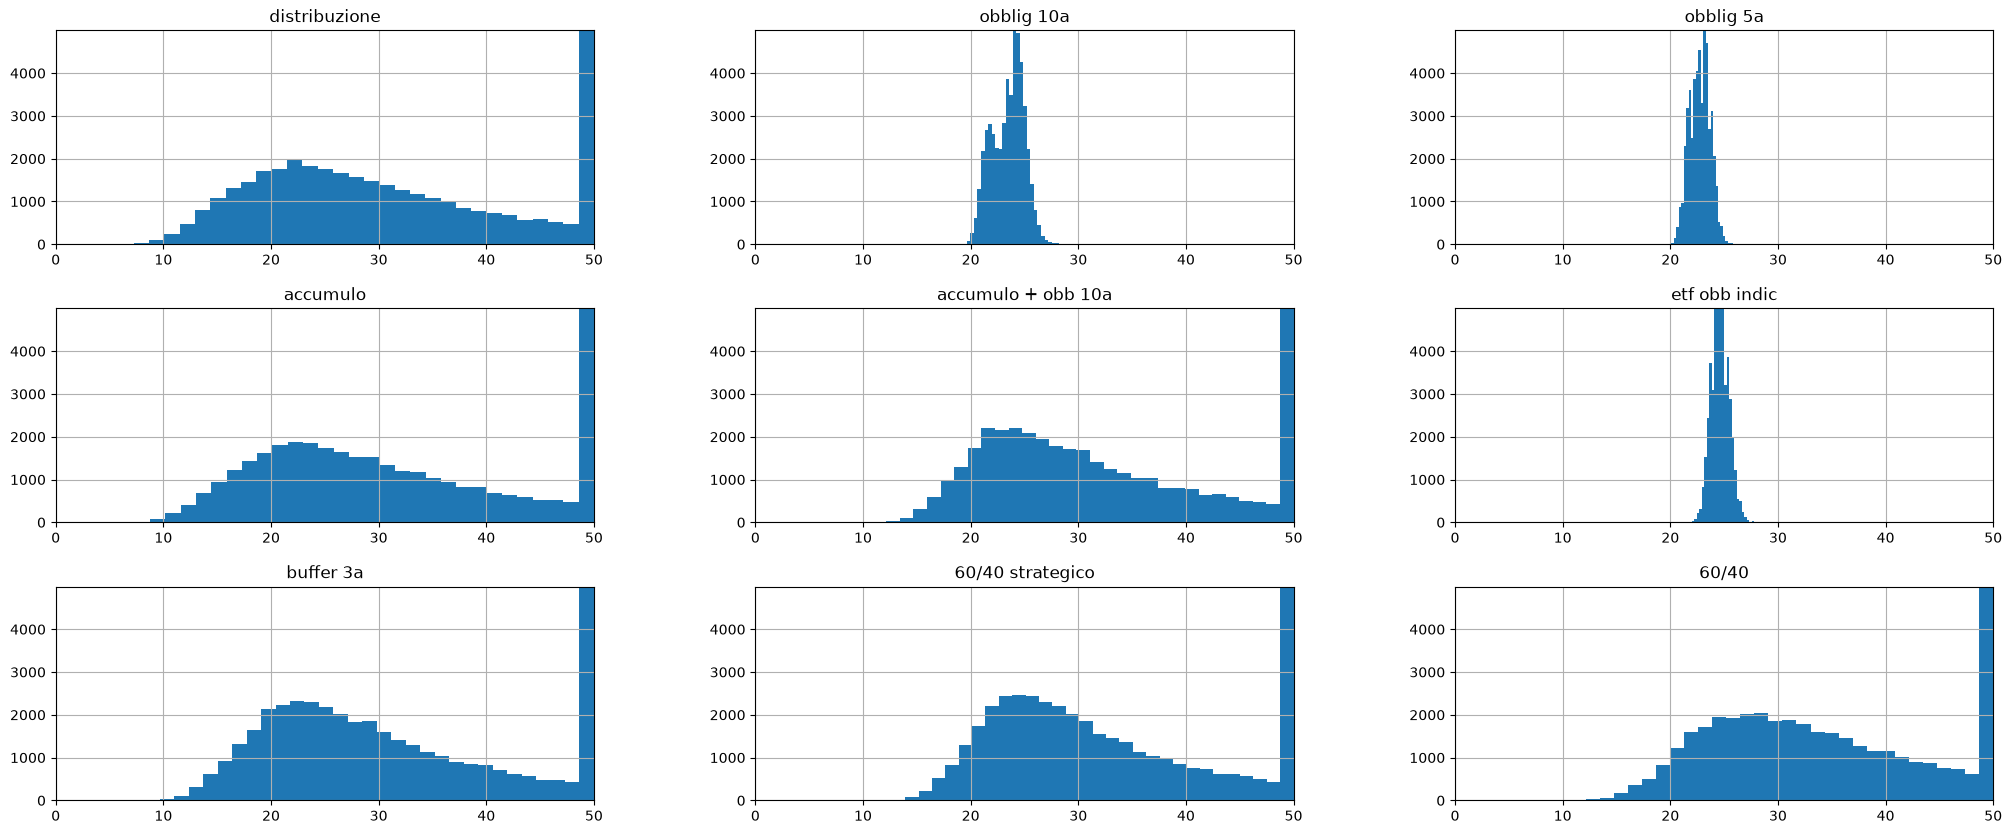

In [45]:
temp = sopravvive[6:].copy()
xmin = (temp/12).min().min()
xmax = (temp/12).max().max()
axes = (temp/12).hist(bins=int(anni_simulazione*12/20), figsize=(25, 10))
for ax in axes.flatten():
    ax.set_xlim(0,xmax)
    ax.set_ylim(0,len((temp/12).dropna())/10)

## Problemi

Usare la media quando estraggo l'inflazione e i rendimento BTP del mese successivo smussa molto gli shock inflattivi e di rendimento BTP, regalando un po' meno problemi di inflazione.

## Sviluppi

Implementare 60/40 tramite un ETF tipo Lifestrategy, cioè che ribilanci ma senza tasse. E' facile da fare calcolando i rendimenti mensili dei due asset, creando un rendimento che è sempre il 60/40 dei rendimenti e poi ricostruendo la sequenza. Infine investi in questo come se fosse un asset ad accumulo.

Implementare una strategia con numerosi ETF differenti ma che tracciano lo stesso indice, comprati in periodi differenti e con prezzi di carico differenti. Si vende quello con prezzo attuale più vicino al suo prezzo di carico.